<center><h1>Enriquez_Scott_HW2</h1></center>
<br>
<br>

Name: Scott Enriquez
<br>
GitHub Username: `scottenriquez`
<br>

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
%pip install -q matplotlib==3.11.2 numpy==2.5.3 odfpy==1.4.1 "pandas[output-formatting]==3.0.6" scikit-learn==1.9.1 seaborn==0.13.2 statsmodels==0.15.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

Get the Cycle Power Plant Data Set

In [3]:
power_plant_data = pd.read_excel('CCPP/Folds5x2_pp.ods', header=0, sheet_name='Sheet1')

### (b) Exploring the data

#### i. rows and columns

There are 9,568 rows (excluding the header row) and five columns. Each row represents an hourly average of the values. Each of the five columns contain floating point numbers. `AT` refers to the hourly average of ambient temperature. `AP` refers to ambient pressure. `RH` represents relative humidity. `V` refers to exhaust vacuum. These four columns are the features (independent variables) for the linear regression model. `PE`, the net hourly energy output, is the target (dependent variable).

In [4]:
display(power_plant_data.shape)
display(power_plant_data.columns)
display(power_plant_data['AT'].dtypes)
display(power_plant_data['V'].dtypes)
display(power_plant_data['AP'].dtypes)
display(power_plant_data['RH'].dtypes)
display(power_plant_data['PE'].dtypes)

(9568, 5)

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')

dtype('float64')

dtype('float64')

dtype('float64')

dtype('float64')

dtype('float64')

#### ii. pairwise scatterplots of all the variables
See below for detailed findings after adding a hue for `PE` quartile to the scatterplots.

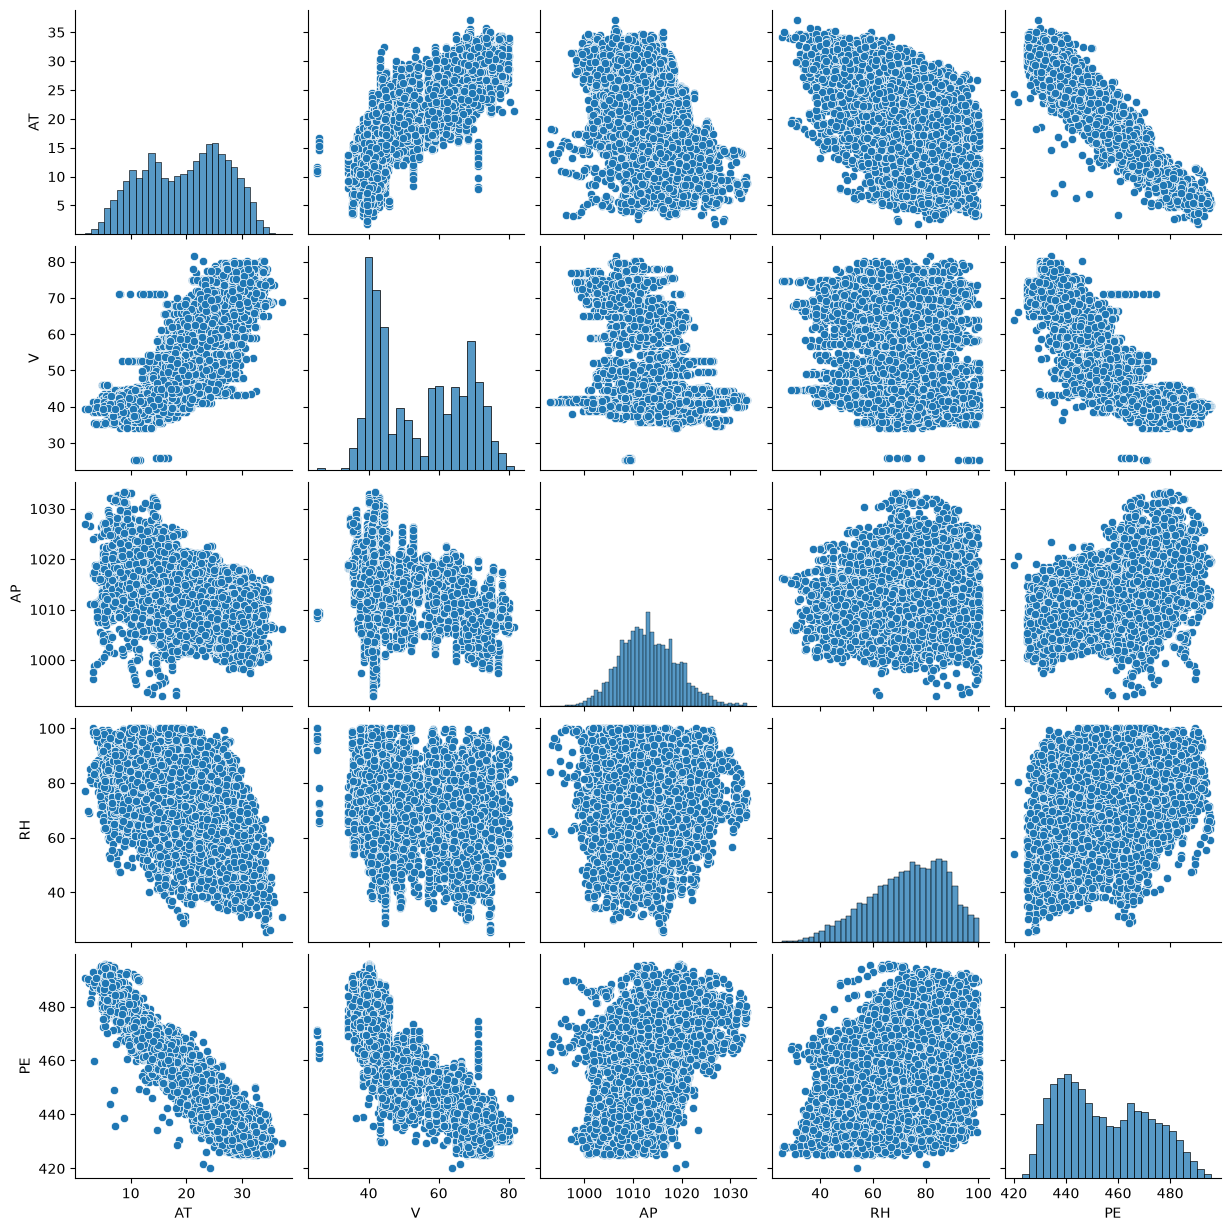

In [5]:
sns.pairplot(power_plant_data)
plt.show()

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [6]:
statistics = power_plant_data.describe().transpose()
statistics.rename(columns={'50%': 'median'}, inplace=True)
statistics['range'] = statistics['max'] - statistics['min']
statistics['iqr'] = statistics['75%'] - statistics['25%']
display(statistics.style.set_caption('Power Plant Data Statistics'))

,count,mean,std,min,25%,median,75%,max,range,iqr
AT,9568.000000,19.651231,7.452473,1.810000,13.510000,20.345000,25.720000,37.110000,35.300000,12.210000
V,9568.000000,54.305804,12.707893,25.360000,41.740000,52.080000,66.540000,81.560000,56.200000,24.800000
AP,9568.000000,1013.259078,5.938784,992.890000,1009.100000,1012.940000,1017.260000,1033.300000,40.410000,8.160000
RH,9568.000000,73.308978,14.600269,25.560000,63.327500,74.975000,84.830000,100.160000,74.600000,21.502500
PE,9568.000000,454.365009,17.066995,420.260000,439.750000,451.550000,468.430000,495.760000,75.500000,28.680000


##### Updated Pairplots and Correlation Matrix

In [7]:
power_plant_data_with_pe_quartiles = power_plant_data.copy(deep=True)
power_plant_data_with_pe_quartiles['quartile_PE'] = (
    pd.qcut(power_plant_data_with_pe_quartiles['PE'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4']))

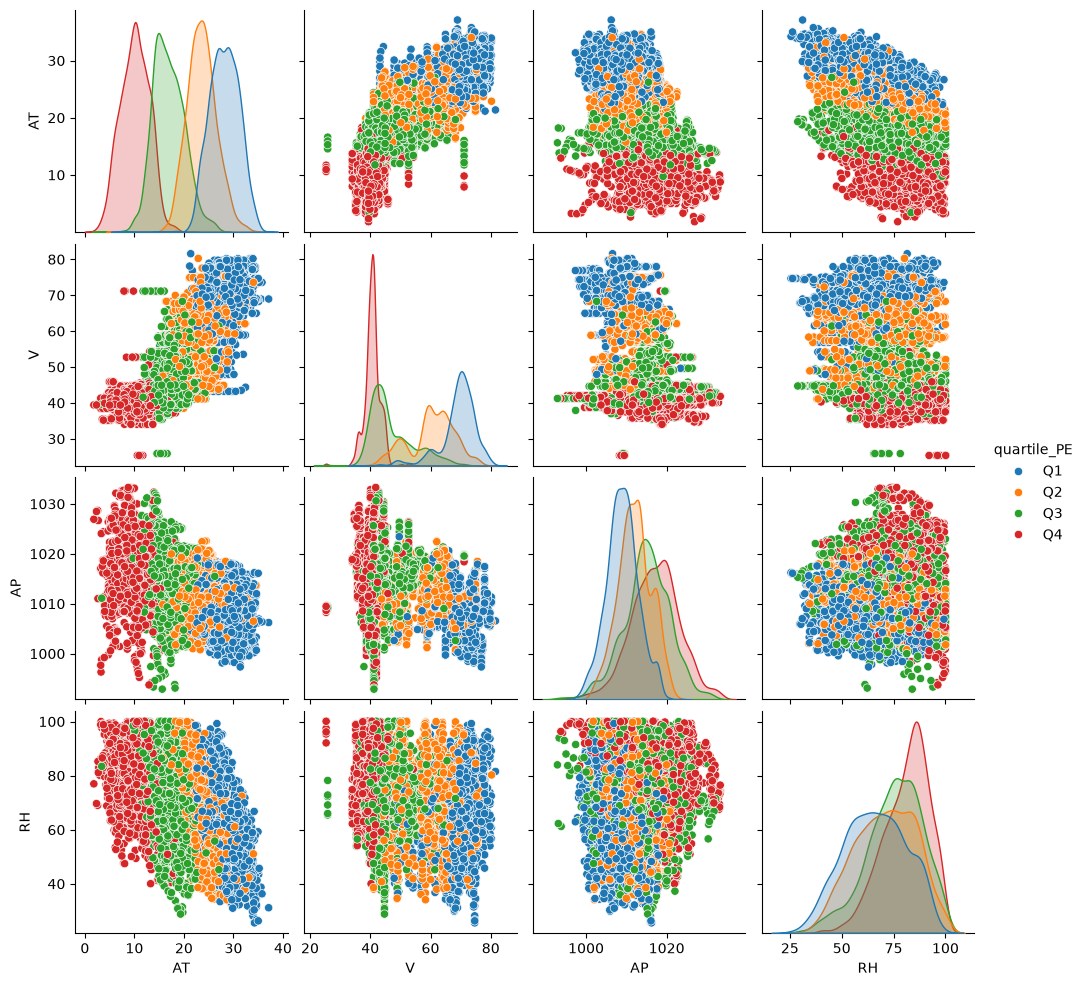

In [8]:
sns.pairplot(power_plant_data_with_pe_quartiles.drop(columns='PE'), hue='quartile_PE')
plt.show()

In [9]:
correlation_matrix = power_plant_data.corr()
display(correlation_matrix.style.set_caption('Correlation Matrix'))

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


##### Variable Analysis for 1(b)ii.

**Note: outlier in this section is defined as +/- 1.5 IQR**

- `AT` has a bimodal distribution. There are no outliers in the `AT` data. `AT` has a very strong positive correlation with `V` and a moderate negative correlation with `AP` and `RH`. It also has a very strong negative correlation with `PE` (i.e., as temperature increases, the power decreases). The `AT`/`PE` panel shows that the relationship is approximately linear.
- `V` has a multimodal distribution. There are no outliers in the `V` data. `V` has a very strong positive relationship with `AT` and a very strong negative relationship with `PE`. The `V`/`PE` panel shows that the relationship is moderately linear.
- `AP` has no very strong relationships. Only moderately positive with `PE`, moderately negative with `AT`, and moderately negative with `V`. There are 88 outliers in the `AP` data. `AP` has an approximately linear relationship with `PE`.
- `RH` has no very strong relationships. Only moderately negative with `AT`, weakly negative with `V`, and weakly positive with `PE`. There are 12 outliers in the `RH` data. `RH` has an approximately linear relationship with `PE`.

### (c) Simple Linear Regression

##### `scikit-learn` Linear Regression Implementation

In [10]:
scikit_learn_results = []
for feature in power_plant_data.columns.drop('PE'):
    regression = LinearRegression().fit(power_plant_data[[feature]], power_plant_data['PE'])
    r_squared = regression.score(power_plant_data[[feature]], power_plant_data['PE'])
    scikit_learn_results.append([feature, r_squared, regression.coef_, regression.intercept_])
scikit_learn_results_summary = pd.DataFrame(scikit_learn_results,
                                            columns=['feature', 'r_squared', 'coefficient', 'intercept'])
display(scikit_learn_results_summary.style.set_caption('scikit-learn Results Summary').hide(axis='index'))

feature,r_squared,coefficient,intercept
AT,0.898948,[-2.17131996],497.034120
V,0.756518,[-1.16813513],517.801526
AP,0.268769,[1.48987167],-1055.260989
RH,0.151939,[0.4556501],420.961766


##### `statsmodels` Linear Regression Implementation (Ordinary Least Squares)

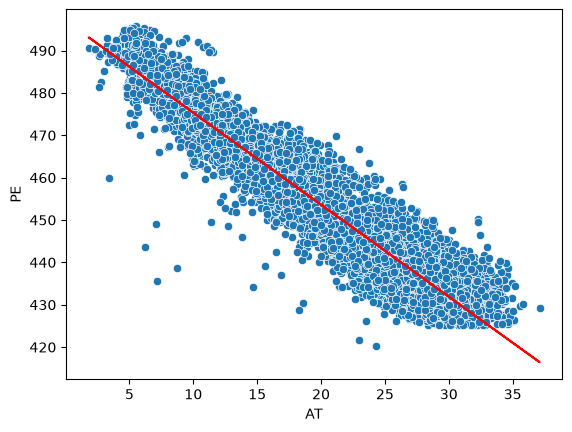

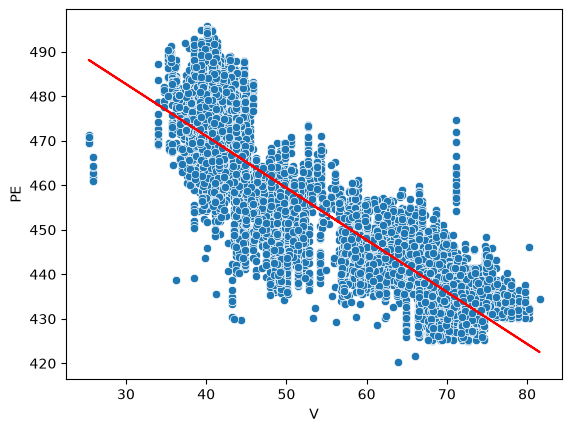

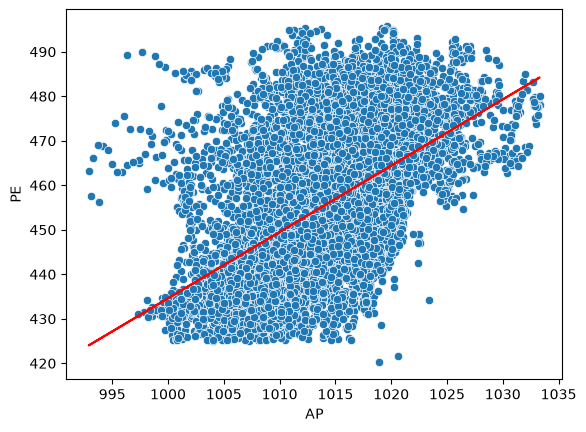

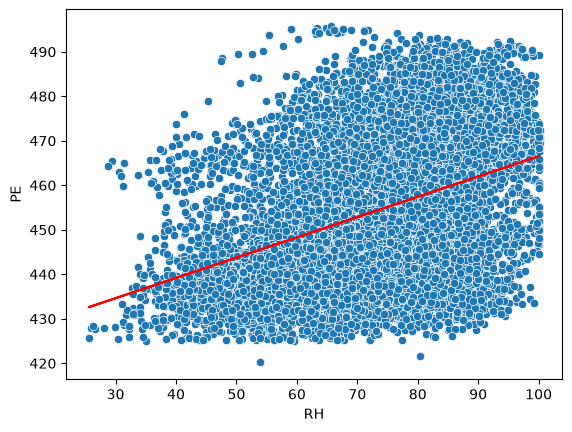

feature,p_values,t_values,standard_error,r_squared,coefficient,intercept
AT,0.000000,-291.715195,0.007443,0.898948,-2.171320,497.034120
V,0.000000,-172.401540,0.006776,0.756518,-1.168135,517.801526
AP,0.000000,59.296232,0.025126,0.268769,1.489872,-1055.260989
RH,0.000000,41.398730,0.011006,0.151939,0.455650,420.961766


In [11]:
statsmodels_results = []
for feature in power_plant_data.columns.drop('PE'):
    model = sm.OLS(power_plant_data['PE'], sm.add_constant(power_plant_data[[feature]]))
    results = model.fit()
    sns.scatterplot(data=power_plant_data, x=feature, y='PE')
    plt.plot(power_plant_data[feature], results.fittedvalues, color='red')
    plt.show()
    statsmodels_results.append(
        [feature, results.pvalues[feature], results.tvalues[feature], results.bse[feature], results.rsquared,
         results.params[feature],
         results.params['const']])
statsmodels_results_summary = (
    pd.DataFrame(statsmodels_results,
                 columns=['feature', 'p_values', 't_values', 'standard_error', 'r_squared',
                          'coefficient', 'intercept']))
display(statsmodels_results_summary.style.set_caption('statsmodels Results Summary').hide(axis='index'))

##### Outlier Research

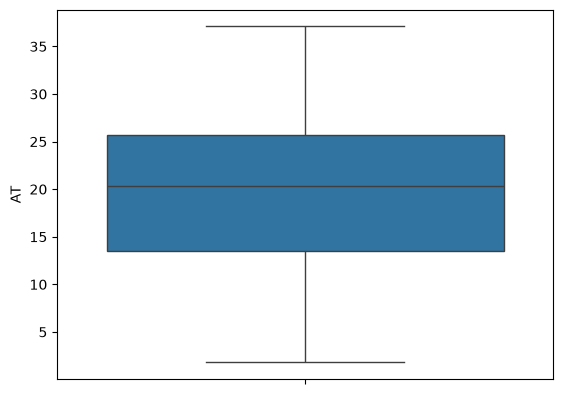

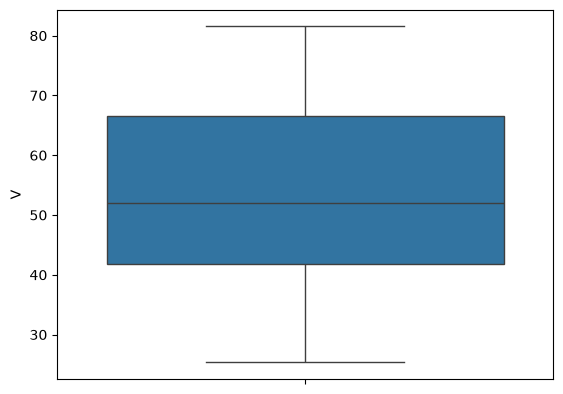

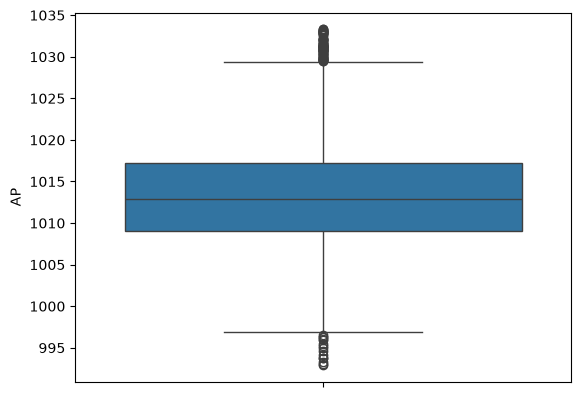

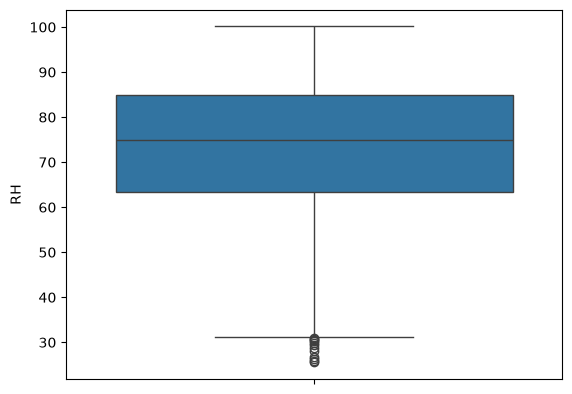

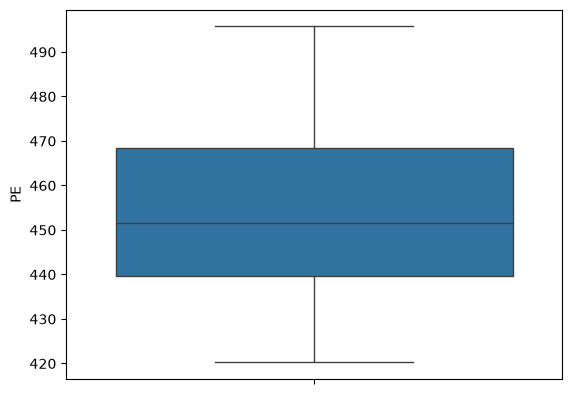

In [12]:
for column in power_plant_data.columns:
    sns.boxplot(power_plant_data[column])
    plt.show()

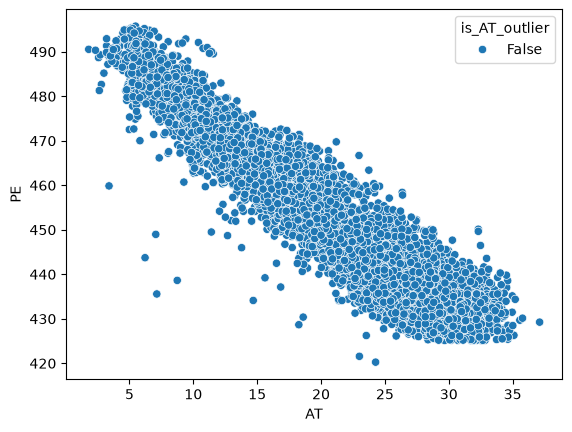

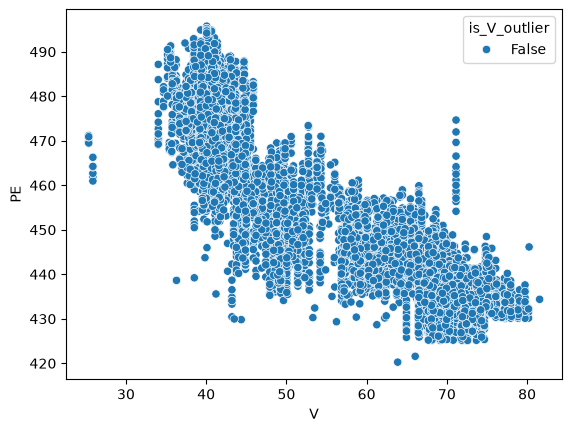

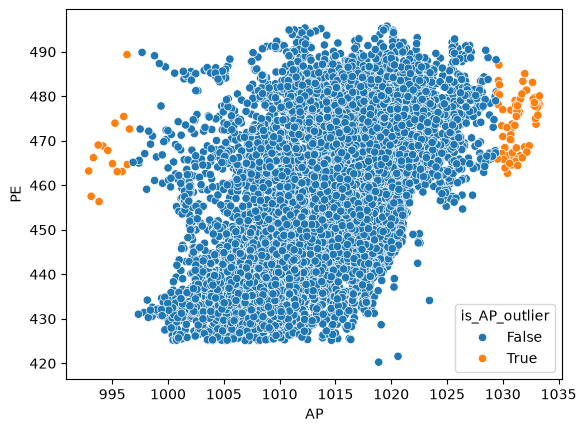

'Column AP outlier count: 88'

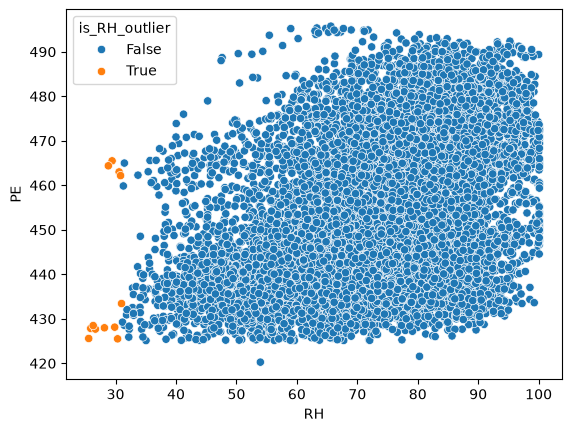

'Column RH outlier count: 12'

In [13]:
power_plant_data_with_outliers_flagged = power_plant_data.copy(deep=True)
for column in power_plant_data_with_outliers_flagged.columns:
    column_first_quartile = statistics.loc[column, '25%']
    column_third_quartile = statistics.loc[column, '75%']
    column_iqr = statistics.loc[column, 'iqr']
    power_plant_data_with_outliers_flagged[f'is_{column}_outlier'] = (
            (power_plant_data_with_outliers_flagged[column] < column_first_quartile - 1.5 * column_iqr)
            | (power_plant_data_with_outliers_flagged[column] > column_third_quartile + 1.5 * column_iqr)
    )
for column in power_plant_data.columns:
    if column != 'PE':
        sns.scatterplot(data=power_plant_data_with_outliers_flagged, x=column, y='PE', hue=f'is_{column}_outlier')
        plt.show()
    column_outlier_count = power_plant_data_with_outliers_flagged[f'is_{column}_outlier'].sum()
    if column_outlier_count > 0:
        display(f'Column {column} outlier count: {column_outlier_count}')

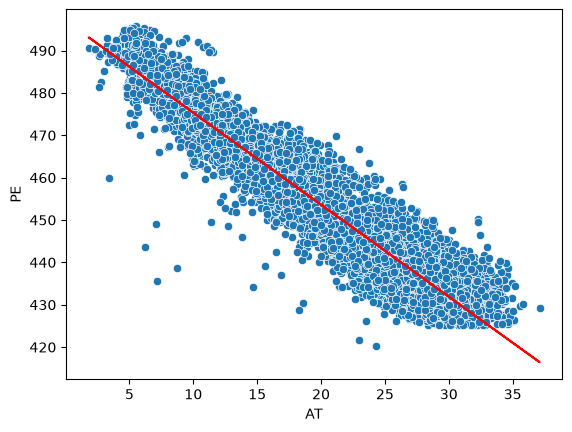

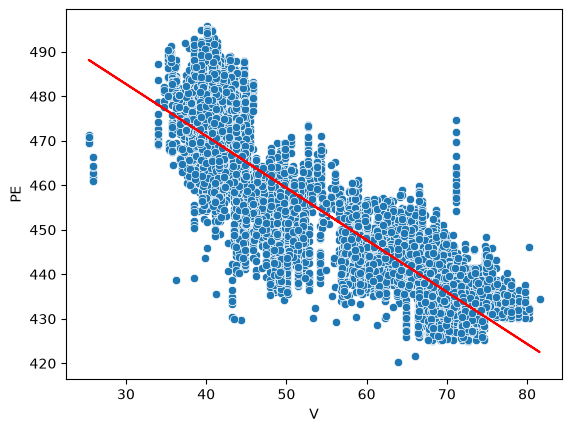

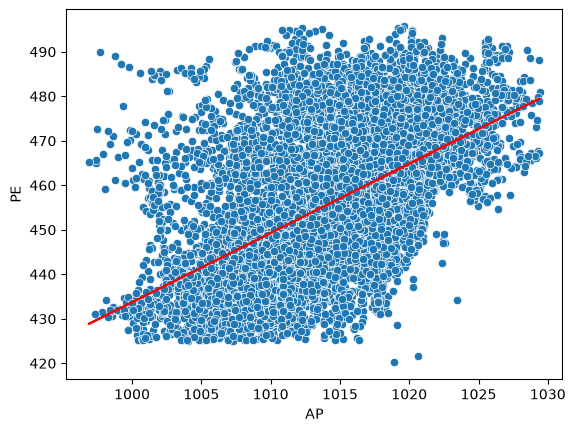

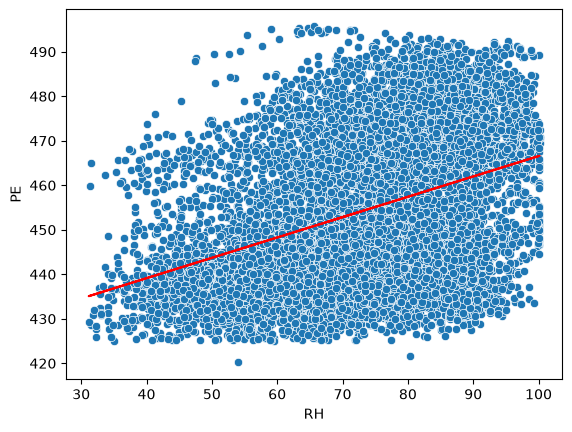

feature,rows_removed,p_values,t_values,standard_error,r_squared,coefficient,intercept
AT,0,0.000000,-291.715195,0.007443,0.898948,-2.171320,497.034120
V,0,0.000000,-172.401540,0.006776,0.756518,-1.168135,517.801526
AP,88,0.000000,59.431158,0.026191,0.271487,1.556542,-1122.817500
RH,12,0.000000,41.296206,0.011070,0.151463,0.457153,420.844013


In [14]:
statsmodels_without_outliers_results = []
for feature in power_plant_data.columns.drop('PE'):
    power_plant_data_without_outliers = power_plant_data_with_outliers_flagged[
        ~power_plant_data_with_outliers_flagged[f'is_{feature}_outlier']
    ]
    model = sm.OLS(power_plant_data_without_outliers['PE'],
                   sm.add_constant(power_plant_data_without_outliers[[feature]]))
    results = model.fit()
    sns.scatterplot(data=power_plant_data_without_outliers, x=feature, y='PE')
    plt.plot(power_plant_data_without_outliers[feature], results.fittedvalues, color='red')
    plt.show()
    statsmodels_without_outliers_results.append(
        [feature, len(power_plant_data) - len(power_plant_data_without_outliers), results.pvalues[feature],
         results.tvalues[feature],
         results.bse[feature], results.rsquared,
         results.params[feature],
         results.params['const']])
statsmodels_without_outliers_results_summary = (
    pd.DataFrame(statsmodels_without_outliers_results,
                 columns=['feature', 'rows_removed', 'p_values', 't_values', 'standard_error', 'r_squared',
                          'coefficient', 'intercept']))
display(statsmodels_without_outliers_results_summary.style
        .set_caption('statsmodels Results Summary (Outliers Removed)').hide(axis='index'))

##### 1(c) Summary
All models show a statistically significant association between the predictor and the response (i.e., p-value < 0.05). There were 88 `AP` outlier candidates and 12 `RH` outlier candidates to remove. Upon training new models with the outliers removed, the `r_squared` got worse for `RH` and only slightly better for `AP` (0.2688 to 0.2715). Therefore, I would leave the outliers in the dataset. `AT` performs the best as a single-feature model with a regression line that fits `PE` well. `V` is the clear second place. `AP` and `RH` are not viable as single-feature models.

### (d) Multiple Regression

In [15]:
multiple_regression_model = sm.OLS(power_plant_data['PE'],
                                   sm.add_constant(power_plant_data.drop(columns='PE')))
multiple_regression_results = multiple_regression_model.fit()
multiple_regression_results_rows = []
for feature in power_plant_data.columns.drop('PE'):
    multiple_regression_results_rows.append(
        [feature, multiple_regression_results.pvalues[feature], multiple_regression_results.tvalues[feature],
         multiple_regression_results.bse[feature], multiple_regression_results.params[feature]])
multiple_regression_results_summary = (
    pd.DataFrame(multiple_regression_results_rows,
                 columns=['feature', 'p_values', 't_values', 'standard_error', 'coefficient']))
display(multiple_regression_results_summary.style
        .set_caption('statsmodels Multiple Regression Results Summary').hide(axis='index'))
display(f'r_squared: {multiple_regression_results.rsquared}')
display(f'r_squared_adjusted: {multiple_regression_results.rsquared_adj}')
display(f'intercept: {multiple_regression_results.params['const']}')

feature,p_values,t_values,standard_error,coefficient
AT,0.000000,-129.342024,0.015289,-1.977513
V,0.000000,-32.122109,0.007282,-0.233916
AP,0.000000,6.564086,0.009458,0.062083
RH,0.000000,-37.918473,0.004168,-0.158054


'r_squared: 0.9286960898122536'

'r_squared_adjusted: 0.9286662648994908'

'intercept: 454.60927431531286'

In [16]:
outlier_flag_columns = [f'is_{feature}_outlier' for feature in power_plant_data.columns.drop('PE')]
power_plant_data_without_any_outliers = power_plant_data_with_outliers_flagged[
    ~power_plant_data_with_outliers_flagged[outlier_flag_columns].any(axis=1)
]
multiple_regression_without_outliers_model = sm.OLS(
    power_plant_data_without_any_outliers['PE'],
    sm.add_constant(power_plant_data_without_any_outliers[power_plant_data.columns.drop('PE')]))
multiple_regression_without_outliers_results = multiple_regression_without_outliers_model.fit()
multiple_regression_without_outliers_results_rows = []
for feature in power_plant_data.columns.drop('PE'):
    multiple_regression_without_outliers_results_rows.append(
        [feature, multiple_regression_without_outliers_results.pvalues[feature],
         multiple_regression_without_outliers_results.tvalues[feature],
         multiple_regression_without_outliers_results.bse[feature],
         multiple_regression_without_outliers_results.params[feature]])
multiple_regression_without_outliers_results_summary = (
    pd.DataFrame(multiple_regression_without_outliers_results_rows,
                 columns=['feature', 'p_values', 't_values', 'standard_error', 'coefficient']))
display(multiple_regression_without_outliers_results_summary.style
        .set_caption('statsmodels Multiple Regression Results Summary (Outliers Removed)').hide(axis='index'))
display(f'rows_removed: {len(power_plant_data) - len(power_plant_data_without_any_outliers)}')
display(f'r_squared: {multiple_regression_without_outliers_results.rsquared}')
display(f'r_squared_adjusted: {multiple_regression_without_outliers_results.rsquared_adj}')
display(f'intercept: {multiple_regression_without_outliers_results.params['const']}')

feature,p_values,t_values,standard_error,coefficient
AT,0.000000,-128.481722,0.015369,-1.974624
V,0.000000,-32.052684,0.007308,-0.234240
AP,0.000000,7.494801,0.009902,0.074210
RH,0.000000,-37.777363,0.004203,-0.158764


'rows_removed: 100'

'r_squared: 0.9280964068230855'

'r_squared_adjusted: 0.9280660132509934'

'intercept: 442.3497382073339'



Given that the p-values are less than alpha (assuming 0.05) for all features, we can reject the null hypothesis for each feature.

### (e) 1c Compare to 1d

The `r_squared` value improved from 0.898948 with the best single-feature model (AT) to 0.928696. The value adjusted for feature count is 0.928666 (also an improvement). Therefore, the multiple regression model is superior. Removing outliers for multiple regression similarly had little effect (with better `r_squared` with the outliers included).

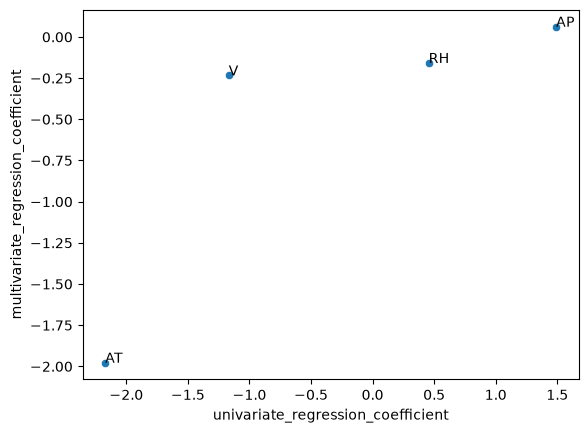

In [17]:
coefficient_comparison = []
indexed_statsmodels_results_summary = statsmodels_results_summary.set_index('feature')
indexed_multiple_regression_results_summary = multiple_regression_results_summary.set_index('feature')
for feature in power_plant_data.columns.drop('PE'):
    coefficient_comparison.append({
        'feature': feature,
        'univariate_regression_coefficient': indexed_statsmodels_results_summary.loc[feature, 'coefficient'],
        'multivariate_regression_coefficient': indexed_multiple_regression_results_summary.loc[feature, 'coefficient']
    })
coefficient_comparison_summary = pd.DataFrame(coefficient_comparison)
sns.scatterplot(data=coefficient_comparison_summary, x='univariate_regression_coefficient',
                y='multivariate_regression_coefficient')
for row in coefficient_comparison_summary.itertuples():
    plt.annotate(row.feature, (row.univariate_regression_coefficient, row.multivariate_regression_coefficient))
plt.show()

`AT` has little change between the models (-2.1713 versus -1.9775). `V` (-1.1681 versus -0.2339) and `AP` (1.4899 versus 0.0621) get closer to zero but maintain the same sign. `RH` (0.4557 versus -0.1581) flips the sign, which is an indication of feature correlation.

### (f) Nonlinear Association

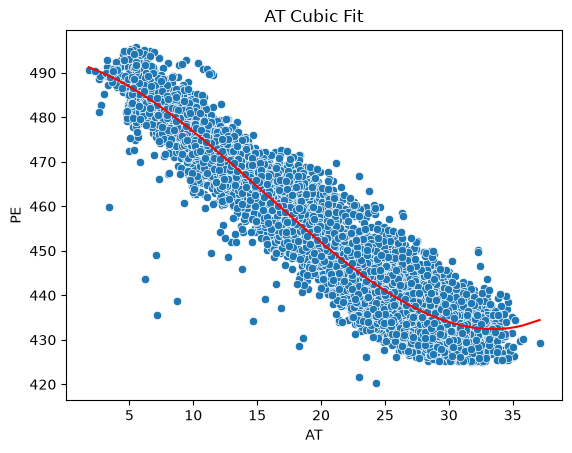

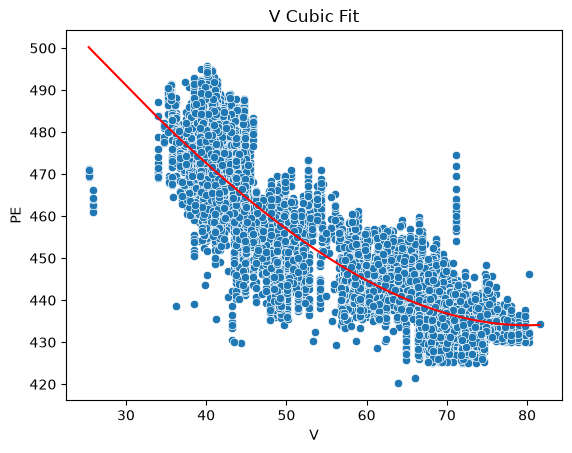

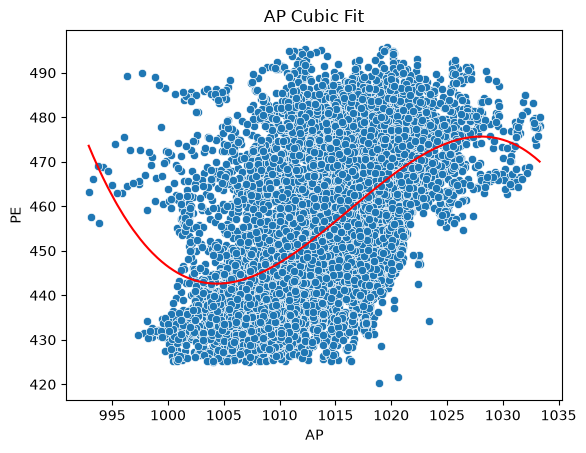

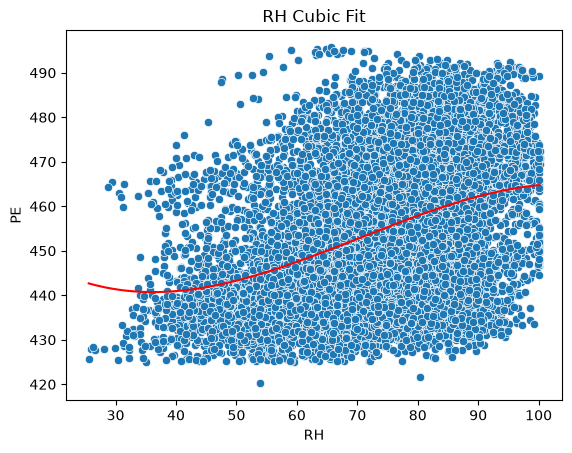

feature,r_squared,linear_p_value,quadratic_p_value,cubic_p_value,linear_coefficient,quadratic_coefficient,cubic_coefficient,intercept
AT,0.911883,0.000000,0.000000,0.000000,-18.106584,1.807852,1.106963,452.708116
V,0.775022,0.000000,0.000000,0.013735,-15.887303,3.096553,0.275685,451.213736
AP,0.297543,0.000000,0.000000,0.000000,11.667100,1.560081,-1.045264,453.082345
RH,0.153743,0.000000,0.101395,0.000014,7.740359,-0.282431,-0.473582,454.442962


In [18]:
nonlinear_results = []
for feature in power_plant_data.columns.drop('PE'):
    # standardizing after issue with AP
    # determined by SingularMatrixWarning when running without standardizing in the Patsy formula
    # caused by AP's range being narrow and far from zero (992.89 to 1033.30)
    # new AP range becomes −3.43 to 3.37 with mean zero
    nonlinear_model = smf.ols(
        f'PE ~ standardize({feature}) + I(standardize({feature})**2) + I(standardize({feature})**3)',
        data=power_plant_data).fit()
    sorted_order = power_plant_data[feature].argsort()
    sns.scatterplot(data=power_plant_data, x=feature, y='PE')
    plt.plot(power_plant_data[feature].iloc[sorted_order],
             nonlinear_model.fittedvalues.iloc[sorted_order], color='red')
    plt.title(f'{feature} Cubic Fit')
    plt.show()
    nonlinear_results.append(
        [feature, nonlinear_model.rsquared,
         nonlinear_model.pvalues.iloc[1], nonlinear_model.pvalues.iloc[2], nonlinear_model.pvalues.iloc[3],
         nonlinear_model.params.iloc[1], nonlinear_model.params.iloc[2], nonlinear_model.params.iloc[3],
         nonlinear_model.params['Intercept']])
nonlinear_results_summary = (
    pd.DataFrame(nonlinear_results,
                 columns=['feature', 'r_squared',
                          'linear_p_value', 'quadratic_p_value', 'cubic_p_value',
                          'linear_coefficient', 'quadratic_coefficient', 'cubic_coefficient',
                          'intercept']))
display(nonlinear_results_summary.style.set_caption('Nonlinear Results Summary').hide(axis='index'))

Based on the quadratic and cubic p-values, there is evidence of nonlinear association between all features and `PE`. `AT`, `V`, and `AP` have linear, quadratic, and cubic p-values all less than 0.05. `RH` has linear and cubic p-values less than 0.05 (but not quadratic).

### (g) Interactions of Predictors

In [19]:
interaction_model = smf.ols('PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH',
                            data=power_plant_data).fit()
display(interaction_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:38:03   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.000     531.631     839.934
AT            -4.3470      2.373     -1.832      0.067      -8.999       0.305
V             -7.6749      1.351     -5.682      0.000     -10.323      -5.027
AP            -0.1524      0.077     -1.983      0.047      -0.303      -0.002
RH             1.5709      0.773      2.031      0.042       0.055       3.087
AT:V           0.0210      0.001     23.338      0.000       0.019       0.023
AT:AP          0.0018      0.002      0.752      0.452      -0.003       0.006
AT:RH         -0.0052      0.001     -6.444      0.000      -0.007      -0.004
V:AP           0.0068      0.001      5.135      0.000       0.004       0.009
V:RH           0.0008      0.000      1.716      0.086      -0.000       0.002
AP:RH         -0.0016      0.001     -2.125      0.034      -0.003      -0.000
==============================================================================
Omnibus:                     1454.609   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9170.848
Skew:                          -0.574   Prob(JB):                         0.00
Kurtosis:                       7.657   Cond. No.                     1.70e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.7e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

`AT:V`, `AT:RH`, `V:AP`, and `AP:RH` interaction terms are statistically significant.

### (h) Improvement

In [20]:
training_data, test_data = train_test_split(power_plant_data, test_size=0.3, random_state=9999)
baseline_model = smf.ols('PE ~ AT + V + AP + RH', data=training_data).fit()
display(baseline_model.summary(title='Baseline Model'))
nonlinear_model_with_interactions = smf.ols('PE ~ (AT + V + AP + RH)**2 + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)',
                                            data=training_data).fit()
display(nonlinear_model_with_interactions.summary(title='Nonlinear Model with Interactions'))

<class 'statsmodels.iolib.summary.Summary'>
"""
                                Baseline Model                                
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:38:03   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.2146     11.523     39.419      0.000     431.626     476.803
AT            -1.9570      0.018   -106.887      0.000      -1.993      -1.921
V             -0.2420      0.009    -27.774      0.000      -0.259      -0.225
AP             0.0622      0.011      5.562      0.000       0.040       0.084
RH            -0.1538      0.005    -30.946      0.000      -0.164      -0.144
==============================================================================
Omnibus:                      642.182   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2717.490
Skew:                          -0.395   Prob(JB):                         0.00
Kurtosis:                       6.019   Cond. No.                     2.11e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.11e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Nonlinear Model with Interactions                       
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7215.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:38:03   Log-Likelihood:                -19181.
No. Observations:                6697   AIC:                         3.839e+04
Df Residuals:                    6682   BIC:                         3.849e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8965.9942   1425.236     -6.291      0.000   -1.18e+04   -6172.077
AT            -6.0939      3.655     -1.667      0.096     -13.259       1.071
V             -1.8148      1.776     -1.022      0.307      -5.296       1.667
AP            18.4768      2.765      6.683      0.000      13.057      23.896
RH             3.6808      1.037      3.549      0.000       1.648       5.714
AT:V           0.0117      0.003      3.635      0.000       0.005       0.018
AT:AP          0.0034      0.004      0.960      0.337      -0.004       0.010
AT:RH         -0.0056      0.002     -3.075      0.002      -0.009      -0.002
V:AP           0.0014      0.002      0.817      0.414      -0.002       0.005
V:RH           0.0002      0.001      0.213      0.831      -0.001       0.002
AP:RH         -0.0034      0.001     -3.384      0.001      -0.005      -0.001
I(AT ** 2)     0.0159      0.004      4.308      0.000       0.009       0.023
I(V ** 2)     -0.0016      0.001     -1.654      0.098      -0.003       0.000
I(AP ** 2)    -0.0090      0.001     -6.709      0.000      -0.012      -0.006
I(RH ** 2)    -0.0018      0.000     -5.606      0.000      -0.002      -0.001
==============================================================================
Omnibus:                     1152.474   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7158.878
Skew:                          -0.677   Prob(JB):                         0.00
Kurtosis:                       7.881   Cond. No.                     2.83e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.83e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [21]:
# first pruning iteration
# removing V:RH
first_pruning_iteration_model = smf.ols(
    'PE ~ (AT + AP + RH)**2 + V + AT:V + V:AP + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)', data=training_data).fit()
display(first_pruning_iteration_model.summary(title='Nonlinear Model with Interactions (Pruning Iteration 1)'))

<class 'statsmodels.iolib.summary.Summary'>
"""
           Nonlinear Model with Interactions (Pruning Iteration 1)            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7771.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:38:03   Log-Likelihood:                -19181.
No. Observations:                6697   AIC:                         3.839e+04
Df Residuals:                    6683   BIC:                         3.849e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8946.9411   1422.329     -6.290      0.000   -1.17e+04   -6158.723
AT            -6.2918      3.535     -1.780      0.075     -13.221       0.638
AP            18.4402      2.759      6.683      0.000      13.031      23.849
RH             3.6341      1.014      3.585      0.000       1.647       5.621
AT:AP          0.0036      0.003      1.039      0.299      -0.003       0.010
AT:RH         -0.0053      0.001     -5.342      0.000      -0.007      -0.003
AP:RH         -0.0033      0.001     -3.415      0.001      -0.005      -0.001
V             -1.7000      1.692     -1.005      0.315      -5.018       1.617
AT:V           0.0113      0.002      4.598      0.000       0.006       0.016
V:AP           0.0013      0.002      0.789      0.430      -0.002       0.005
I(AT ** 2)     0.0164      0.003      5.726      0.000       0.011       0.022
I(V ** 2)     -0.0015      0.001     -1.740      0.082      -0.003       0.000
I(AP ** 2)    -0.0090      0.001     -6.709      0.000      -0.012      -0.006
I(RH ** 2)    -0.0017      0.000     -6.202      0.000      -0.002      -0.001
==============================================================================
Omnibus:                     1152.510   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7156.624
Skew:                          -0.677   Prob(JB):                         0.00
Kurtosis:                       7.880   Cond. No.                     2.83e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.83e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [22]:
# second pruning iteration
# removing V:AP
second_pruning_iteration_model = smf.ols('PE ~ (AT + AP + RH)**2 + V + AT:V + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)',
                                         data=training_data).fit()
display(second_pruning_iteration_model.summary(title='Nonlinear Model with Interactions (Pruning Iteration 2)'))

<class 'statsmodels.iolib.summary.Summary'>
"""
           Nonlinear Model with Interactions (Pruning Iteration 2)            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     8419.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:38:03   Log-Likelihood:                -19182.
No. Observations:                6697   AIC:                         3.839e+04
Df Residuals:                    6684   BIC:                         3.848e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8833.3457   1414.985     -6.243      0.000   -1.16e+04   -6059.524
AT            -8.4124      2.296     -3.664      0.000     -12.914      -3.911
AP            18.2008      2.742      6.637      0.000      12.825      23.577
RH             3.4317      0.981      3.500      0.000       1.509       5.354
AT:AP          0.0057      0.002      2.582      0.010       0.001       0.010
AT:RH         -0.0052      0.001     -5.326      0.000      -0.007      -0.003
AP:RH         -0.0031      0.001     -3.324      0.001      -0.005      -0.001
V             -0.3657      0.065     -5.623      0.000      -0.493      -0.238
AT:V           0.0106      0.002      4.609      0.000       0.006       0.015
I(AT ** 2)     0.0172      0.003      6.367      0.000       0.012       0.023
I(V ** 2)     -0.0014      0.001     -1.673      0.094      -0.003       0.000
I(AP ** 2)    -0.0089      0.001     -6.662      0.000      -0.011      -0.006
I(RH ** 2)    -0.0018      0.000     -6.224      0.000      -0.002      -0.001
==============================================================================
Omnibus:                     1153.042   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7143.631
Skew:                          -0.678   Prob(JB):                         0.00
Kurtosis:                       7.875   Cond. No.                     2.81e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.81e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
# third pruning iteration
# removing V ** 2
third_pruning_iteration_model = smf.ols('PE ~ (AT + AP + RH)**2 + V + AT:V + I(AT**2) + I(AP**2) + I(RH**2)',
                                        data=training_data).fit()
display(third_pruning_iteration_model.summary(title='Nonlinear Model with Interactions (Pruning Iteration 3)'))

<class 'statsmodels.iolib.summary.Summary'>
"""
           Nonlinear Model with Interactions (Pruning Iteration 3)            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:38:03   Log-Likelihood:                -19183.
No. Observations:                6697   AIC:                         3.839e+04
Df Residuals:                    6685   BIC:                         3.847e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8918.5107   1414.258     -6.306      0.000   -1.17e+04   -6146.113
AT            -8.4071      2.296     -3.661      0.000     -12.909      -3.905
AP            18.3625      2.741      6.699      0.000      12.989      23.736
RH             3.5280      0.979      3.603      0.000       1.609       5.447
AT:AP          0.0058      0.002      2.624      0.009       0.001       0.010
AT:RH         -0.0054      0.001     -5.514      0.000      -0.007      -0.003
AP:RH         -0.0032      0.001     -3.421      0.001      -0.005      -0.001
V             -0.4605      0.032    -14.490      0.000      -0.523      -0.398
AT:V           0.0076      0.001      5.259      0.000       0.005       0.010
I(AT ** 2)     0.0192      0.002      7.968      0.000       0.015       0.024
I(AP ** 2)    -0.0089      0.001     -6.722      0.000      -0.012      -0.006
I(RH ** 2)    -0.0018      0.000     -6.334      0.000      -0.002      -0.001
==============================================================================
Omnibus:                     1153.565   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7115.747
Skew:                          -0.680   Prob(JB):                         0.00
Kurtosis:                       7.863   Cond. No.                     2.81e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.81e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
baseline_model_train_mse = mean_squared_error(training_data['PE'], baseline_model.fittedvalues)
baseline_model_test_mse = mean_squared_error(test_data['PE'], baseline_model.predict(test_data))
pruned_model_train_mse = mean_squared_error(training_data['PE'], third_pruning_iteration_model.fittedvalues)
pruned_model_test_mse = mean_squared_error(test_data['PE'], third_pruning_iteration_model.predict(test_data))
mse_results_summary = pd.DataFrame(
    [[baseline_model_train_mse, baseline_model_test_mse], [pruned_model_train_mse, pruned_model_test_mse]],
    columns=['Training MSE', 'Test MSE'],
    index=['Baseline', 'Pruned'])
display(mse_results_summary.style.set_caption('MSE Results Summary'))

,Training MSE,Test MSE
Baseline,20.581045,21.218629
Pruned,18.011368,18.380621


In summary, adding interaction terms and nonlinear associations (with pruned features) improves the test MSE by 13.4% and the training MSE by 12.5%.

### (i) KNN

##### Raw Features

,1/k,k,training_data_mse,test_data_mse
4,0.200000,5,10.580480,16.024731
5,0.166667,6,11.453850,16.164350
3,0.250000,4,9.615856,16.297782
6,0.142857,7,12.012044,16.375047
7,0.125000,8,12.635659,16.609637
8,0.111111,9,13.033767,16.674022
2,0.333333,3,8.042527,16.791554
9,0.100000,10,13.463542,16.943253
10,0.090909,11,13.849764,17.068265
11,0.083333,12,14.114576,17.221376


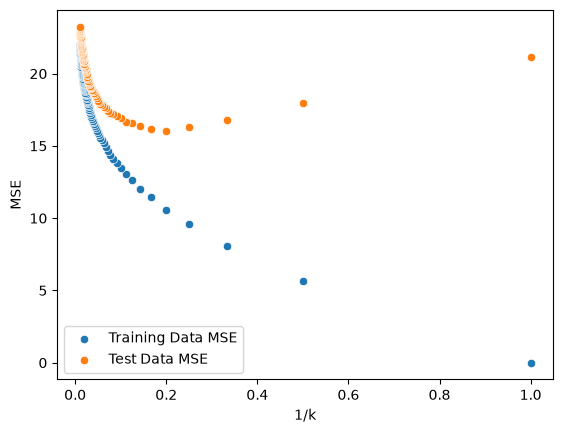

In [25]:
k_neighbors_regressor_results = []
for k in range(1, 101, 1):
    k_neighbors_regressor = KNeighborsRegressor(n_neighbors=k)
    k_neighbors_regressor.fit(training_data.drop(columns='PE'), training_data['PE'])
    training_data_predictions = k_neighbors_regressor.predict(training_data.drop(columns='PE'))
    test_data_predictions = k_neighbors_regressor.predict(test_data.drop(columns='PE'))
    k_neighbors_regressor_results.append({
        '1/k': 1 / k,
        'k': k,
        'training_data_mse': mean_squared_error(training_data['PE'], training_data_predictions),
        'test_data_mse': mean_squared_error(test_data['PE'], test_data_predictions),
    })
k_neighbors_regressor_results_summary = (
    pd.DataFrame(k_neighbors_regressor_results).sort_values('test_data_mse', ascending=True))
display(k_neighbors_regressor_results_summary.head(25).style.set_caption('KNN Regressor Results Summary (Top 25)'))
sns.scatterplot(data=k_neighbors_regressor_results_summary, x='1/k', y='training_data_mse', label='Training Data MSE')
sns.scatterplot(data=k_neighbors_regressor_results_summary, x='1/k', y='test_data_mse', label='Test Data MSE')
plt.ylabel('MSE')
plt.legend()
plt.show()

##### Normalized Features

,1/k,k,training_data_mse,test_data_mse
4,0.200000,5,9.499698,15.131970
3,0.250000,4,8.622595,15.149368
5,0.166667,6,10.347241,15.480936
6,0.142857,7,11.025181,15.513837
7,0.125000,8,11.506633,15.522218
8,0.111111,9,11.955786,15.620023
2,0.333333,3,7.366667,15.622913
9,0.100000,10,12.381069,15.723704
10,0.090909,11,12.753341,15.773454
11,0.083333,12,13.035512,15.869403


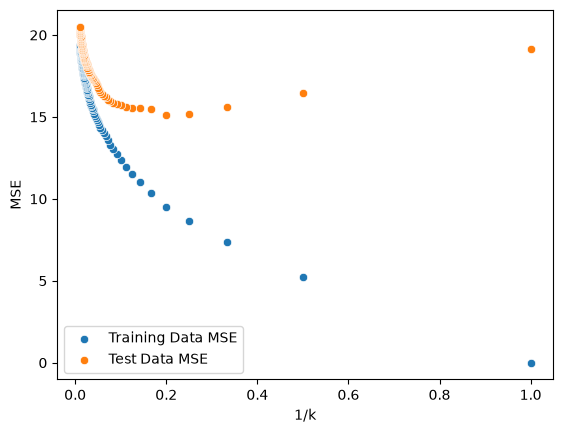

In [26]:
normalized_k_neighbors_regressor_results = []
scaler = StandardScaler().fit(training_data.drop(columns='PE'))
scaled_training_data = scaler.transform(training_data.drop(columns='PE'))
scaled_test_data = scaler.transform(test_data.drop(columns='PE'))
for k in range(1, 101, 1):
    k_neighbors_regressor = KNeighborsRegressor(n_neighbors=k)
    k_neighbors_regressor.fit(scaled_training_data, training_data['PE'])
    training_data_predictions = k_neighbors_regressor.predict(scaled_training_data)
    test_data_predictions = k_neighbors_regressor.predict(scaled_test_data)
    normalized_k_neighbors_regressor_results.append({
        '1/k': 1 / k,
        'k': k,
        'training_data_mse': mean_squared_error(training_data['PE'], training_data_predictions),
        'test_data_mse': mean_squared_error(test_data['PE'], test_data_predictions),
    })
normalized_k_neighbors_regressor_results_summary = (
    pd.DataFrame(normalized_k_neighbors_regressor_results).sort_values('test_data_mse', ascending=True))
display(normalized_k_neighbors_regressor_results_summary.head(25).style.set_caption('Normalized KNN Regressor Results Summary (Top 25)'))
sns.scatterplot(data=normalized_k_neighbors_regressor_results_summary, x='1/k', y='training_data_mse', label='Training Data MSE')
sns.scatterplot(data=normalized_k_neighbors_regressor_results_summary, x='1/k', y='test_data_mse', label='Test Data MSE')
plt.ylabel('MSE')
plt.legend()
plt.show()

The normalized features perform slightly better than raw features in terms of test MSE (15.131970 versus 16.024731) but have the same best `k=5`.

### (j) Compare KNN and Linear

The KNN model with normalized features performs the best out of all models by test MSE (k=5; 15.131970). This model outperformed both the KNN model with raw features (k=5, 16.024731) and the best pruned and nonlinear OLS model (18.380621).

While initially surprising that KNN performed the best, the evidence of nonlinear associations, large `n` and small `p`, and nonparametric approach make sense on why a flexible model like KNN would outperform an inflexible model like OLS linear regression (even though adding nonlinearity did improve MSE). Choosing KNN does come with tradeoffs. Namely, it's a far less explainable model since there are no coefficients.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Flexible methods will likley perform better. Small `p` means smaller distances (i.e., higher density). Given the large `n`, there's less risk of variance (assuming random sampling).

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Inflexible methods will likely perform better. Given the small `n`, flexible methods would have extremely high variance. The large `p` worses this due to the low density of data.

### (c) The relationship between the predictors and response is highly non-linear.

Flexible methods will likely perform better due to the lower bias. Given than the relationship is highly non-linear, the less that we assume about the shape of `f(x)`, the more accurate our predictions will likely be.

### (d) The variance of the error terms, i.e. $\sigma^2 = \mathrm{Var}(\epsilon)$, is extremely high.

Inflexible methods will likely perform better given the high variance of irreducible error. By making stricter assumptions about the shape of `f(x)` our predictions will be less susceptible to overfitting.

## 3. ISLR: 2.4.7

In [27]:
islr_2_4_7_training_data = pd.DataFrame(
    [[0, 3, 0, 'Red'],
     [2, 0, 0, 'Red'],
     [0, 1, 3, 'Red'],
     [0, 1, 2, 'Green'],
     [-1, 0, 1, 'Green'],
     [1, 1, 1, 'Red']],
    columns=['x1', 'x2', 'x3', 'y'],
    index=pd.Index([1, 2, 3, 4, 5, 6], name='observation'))
display(islr_2_4_7_training_data.style.set_caption('ISLR 2.4.7 Training Data'))

,x1,x2,x3,y
observation,,,,
1,0,3,0,Red
2,2,0,0,Red
3,0,1,3,Red
4,0,1,2,Green
5,-1,0,1,Green
6,1,1,1,Red


### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [28]:
a_point = np.array([0, 0, 0])
a_point_euclidean_distances = []
for index, row in islr_2_4_7_training_data.iterrows():
    a_point_euclidean_distances.append({
        'observation': index,
        'distance': np.sqrt(np.sum(np.square(np.array([row['x1'], row['x2'], row['x3']]) - a_point))),
        'y': row['y']
    })
a_point_euclidean_distances_summary = pd.DataFrame(a_point_euclidean_distances).set_index('observation')
display(a_point_euclidean_distances_summary.style.set_caption('Euclidean Distances from (0, 0, 0)'))

,distance,y
observation,,
1,3.000000,Red
2,2.000000,Red
3,3.162278,Red
4,2.236068,Green
5,1.414214,Green
6,1.732051,Red


### (b) What is our prediction with K = 1? Why?

When `k=1`, we choose the `y` label for the closest point as our prediction. In this case, observation 5 has the lowest Euclidean distance, so our prediction is `Green`.

### (c) What is our prediction with K = 3? Why?

When `k=3`, we choose the `y` label as our prediction based on the majority voting of classes using the three closest points. In this case, predictions 2, 5, and 6 are the three closest points. Their labels are `Red`, `Green`, and `Red`. Since there is a clear majority of `Red`, our prediction is `Red`.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the `k` value to be small. Given the flexibility requirement for the nonlinear function, a smaller `k` will satisfy that. A large `k` would introduce more bias.